# Visual Classifier — Evaluation
Compares the **original** `dima806/ai_vs_human_generated_image_detection` model against the
**fine-tuned** version (loaded from `./fine_tuned_model_delta/weight_delta.pt`)
on the test split of `julienlucas/midjourney-dalle-sd-nanobananapro-dataset`.

> ⚠️ **Pre-requisite:** Run `visual_classifier_finetuning.ipynb` first to train the model
> and generate `./fine_tuned_model_delta/weight_delta.pt`.

## 0. Setup

In [1]:
import warnings
warnings.filterwarnings('ignore')

import torch
from datasets import load_dataset
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
from tqdm.notebook import tqdm
from visual_classifier import VisualClassifier

## 1. Load the Test Dataset

In [2]:
dataset = load_dataset('julienlucas/midjourney-dalle-sd-nanobananapro-dataset')
test_dataset = dataset['test']
print(f"Loaded {len(test_dataset)} test examples.")

Loaded 2000 test examples.


## 2. Load Both Models

In [3]:
print("Loading original model...")
original_classifier = VisualClassifier(model_name_or_path="dima806/ai_vs_human_generated_image_detection")
print("Original model ready.")

Loading original model...


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Original model ready.


In [4]:
print("Loading fine-tuned model from local weight delta...")
fine_tuned_classifier = VisualClassifier(
    model_name_or_path="dima806/ai_vs_human_generated_image_detection",
    delta_path="./fine_tuned_model_delta/weight_delta.pt",
)
print("Fine-tuned model ready.")

Loading fine-tuned model from local weight delta...


Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

Applying weight delta from './fine_tuned_model_delta/weight_delta.pt'...
Delta applied successfully.
Fine-tuned model ready.


## 3. Quick Sanity Check — Single Sample

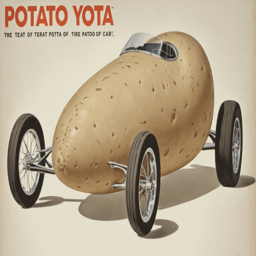

Ground Truth: Real
Original model:   {'prediction': 'Real', 'confidence': 0.9911, 'raw_label': 'human', 'all_scores': {'human': 0.9911, 'AI-generated': 0.0089}}
Fine-tuned model: {'prediction': 'Real', 'confidence': 0.9842, 'raw_label': 'human', 'all_scores': {'human': 0.9842, 'AI-generated': 0.0158}}


In [5]:
from IPython.display import display

label_map = {0: 'Real', 1: 'AI Generated'}

sample_image = test_dataset[0]['image'].convert('RGB')
sample_label = label_map.get(test_dataset[0]['label'], 'Unknown')

display(sample_image.resize((256, 256)))
print(f"Ground Truth: {sample_label}")
print(f"Original model:   {original_classifier.predict(sample_image)}")
print(f"Fine-tuned model: {fine_tuned_classifier.predict(sample_image)}")

## 4. Full Test-Set Evaluation
Runs inference for both models across the entire test split.

In [6]:
# Set a max sample limit if you want to evaluate faster
num_samples = len(test_dataset)
# num_samples = 200  # uncomment for a quick test

orig_true_labels = []
orig_pred_labels = []

ft_true_labels = []
ft_pred_labels = []

for i in tqdm(range(num_samples), desc="Evaluating both models"):
    item = test_dataset[i]
    img = item['image']

    if img.mode != 'RGB':
        img = img.convert('RGB')

    true_label = label_map.get(item['label'], 'Unknown')

    # Original model
    orig_pred = original_classifier.predict(img)['prediction']
    orig_true_labels.append(true_label)
    orig_pred_labels.append(orig_pred)

    # Fine-tuned model
    ft_pred = fine_tuned_classifier.predict(img)['prediction']
    ft_true_labels.append(true_label)
    ft_pred_labels.append(ft_pred)

print("Evaluation complete.")

Evaluating both models:   0%|          | 0/2000 [00:00<?, ?it/s]

Evaluation complete.


## 5. Results — Original Model

In [7]:
print("=== Original Model ===")
print("\nClassification Report:")
print(classification_report(orig_true_labels, orig_pred_labels))

print("Confusion Matrix (rows=True, cols=Predicted):")
print(confusion_matrix(orig_true_labels, orig_pred_labels, labels=["Real", "AI Generated"]))

=== Original Model ===

Classification Report:
              precision    recall  f1-score   support

AI Generated       0.19      0.01      0.02      1000
        Real       0.49      0.96      0.65      1000

    accuracy                           0.48      2000
   macro avg       0.34      0.48      0.33      2000
weighted avg       0.34      0.48      0.33      2000

Confusion Matrix (rows=True, cols=Predicted):
[[957  43]
 [990  10]]


## 6. Results — Fine-Tuned Model

In [8]:
print("=== Fine-Tuned Model ===")
print("\nClassification Report:")
print(classification_report(ft_true_labels, ft_pred_labels))

print("Confusion Matrix (rows=True, cols=Predicted):")
print(confusion_matrix(ft_true_labels, ft_pred_labels, labels=["Real", "AI Generated"]))

=== Fine-Tuned Model ===

Classification Report:
              precision    recall  f1-score   support

AI Generated       0.87      0.91      0.89      1000
        Real       0.90      0.87      0.89      1000

    accuracy                           0.89      2000
   macro avg       0.89      0.89      0.89      2000
weighted avg       0.89      0.89      0.89      2000

Confusion Matrix (rows=True, cols=Predicted):
[[868 132]
 [ 92 908]]


## 7. Side-by-Side Accuracy Comparison

In [9]:
orig_acc = accuracy_score(orig_true_labels, orig_pred_labels)
ft_acc   = accuracy_score(ft_true_labels,   ft_pred_labels)

print(f"Original model accuracy : {orig_acc:.4f} ({orig_acc*100:.2f}%)")
print(f"Fine-tuned model accuracy: {ft_acc:.4f} ({ft_acc*100:.2f}%)")
print(f"Improvement             : {(ft_acc - orig_acc)*100:+.2f} pp")

Original model accuracy : 0.4835 (48.35%)
Fine-tuned model accuracy: 0.8880 (88.80%)
Improvement             : +40.45 pp
